# Notebook 2: Feature Engineering & RFM Analysis

Sections 7–8: RFM (Recency, Frequency, Monetary) analysis, customer segmentation based on RFM scores, and business insights.

**Prerequisite:** Run Notebook 1 first to generate merged.csv and final.csv

**Team role:** Feature Engineering

**Team:** FEHU | **Dataset:** Olist Brazilian E-Commerce | **Track:** Business & Retail

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

merged = pd.read_csv("merged.csv", parse_dates=["order_purchase_timestamp"])
final  = pd.read_csv("final.csv")
print("merged shape:", merged.shape)
print("final shape:", final.shape)

merged shape: (111468, 24)
final shape: (90528, 21)


<a id="rfm"></a>
# 7. RMF Analysis
RFM analysis is a data driven customer behavior segmentation technique.<br> <br>

RFM stands for recency, frequency, and monetary value.<br><br>

The  idea is to segment customers based on when their last purchase was, how often they’ve purchased in the past, and how much they’ve spent overall. All three of these measures have proven to be effective predictors of a customer's willingness to engage in marketing messages and offers.<br>
<img src = "rfm.png" width = "600" height = "600">

<a id="recency"></a>
## 7.1. Recency

In [4]:
recency = merged.groupby('customer_unique_id', as_index=False)['order_purchase_timestamp'].max()
recency.rename(columns={'order_purchase_timestamp':'LastPurchaseDate'},inplace = True)
recency.head()

,customer_unique_id,LastPurchaseDate
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [5]:
recent_date = merged['order_purchase_timestamp'].dt.date.max()
print('The last recent date in the available dataset is: ', recent_date)

The last recent date in the available dataset is:  2018-08-29


In [6]:
recency['Recency'] = recency['LastPurchaseDate'].dt.date.apply(lambda x: (recent_date - x).days)
recency.head()

,customer_unique_id,LastPurchaseDate,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,537
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,321
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,288


**Observations:**
1. The last purchase date of every individual customer is taken using the group by function.
2. **Recency** is calculated by **subtracting the last recent date available** in the dataset with **every customer's last purchase date**. 

<a id="frequency"></a>
## 7.2. Frequency

In [7]:
frequency = merged.groupby(["customer_unique_id"]).agg({"order_id":"nunique"}).reset_index()
frequency.rename(columns={'order_id':'Frequency'},inplace=True)
frequency.head()

,customer_unique_id,Frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


**Observation:**
1. **Frequency** is calculated by selecting the **number of `unique order_id`** or orders placed by each individual customer.

<a id="monetary"></a>
## 7.3. Monetary

In [8]:
monetary = merged.groupby('customer_unique_id', as_index=False)['payment_value'].sum()
monetary.rename(columns={'payment_value':'Monetary'},inplace=True)
monetary.head()

,customer_unique_id,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [9]:
rfm = recency.merge(frequency, on='customer_unique_id')
rfm = rfm.merge(monetary, on='customer_unique_id').drop(columns='LastPurchaseDate')
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


**Observation:**
1. **Monetary** is calculated by **summing up the payment value of each individual customer** who placed one or more orders.

<a id="rfmanalysis"></a>
## 7.4. Analysing the RFM data

In [10]:
rfm[rfm.Recency == 0]

,customer_unique_id,Recency,Frequency,Monetary
1463,0421e7a23f21e5d54efed456aedbc513,0,1,119.42
4454,0c6d7218d5f3fa14514fd29865269993,0,1,178.25
12062,21dbe8eabd00b34492a939c540e2b1a7,0,1,14.29
13032,24ac2b4327e25baf39f2119e4228976a,0,1,93.75
32785,5c58de6fb80e93396e2f35642666b693,0,1,1021.92
43195,7a22d14aa3c3599238509ddca4b93b01,0,1,73.10
45280,7febafa06d9d8f232a900a2937f04338,0,1,61.29
62249,afbcfd0b9c5233e7ccc73428526fbb52,0,1,2486.25
64024,b4dcade04bc548b7e3b0243c801f8c26,0,1,106.95
64767,b701bebbdf478f5500348f03aff62121,0,1,33.23


In [11]:
rfm['Recency'] = rfm.Recency.apply(lambda x: 1 if x == 0 else x)

**Observations:**
1. The recency column had values 0, i.e., a customer came at the last day of the date which we took as the threshold to calculate recency. 
2. 0 in recency should be treated or removed for creating the target variable, i.e., Churn and for further process of scaling or normalization, so the **0 is converted to 1 for our convenience**. 

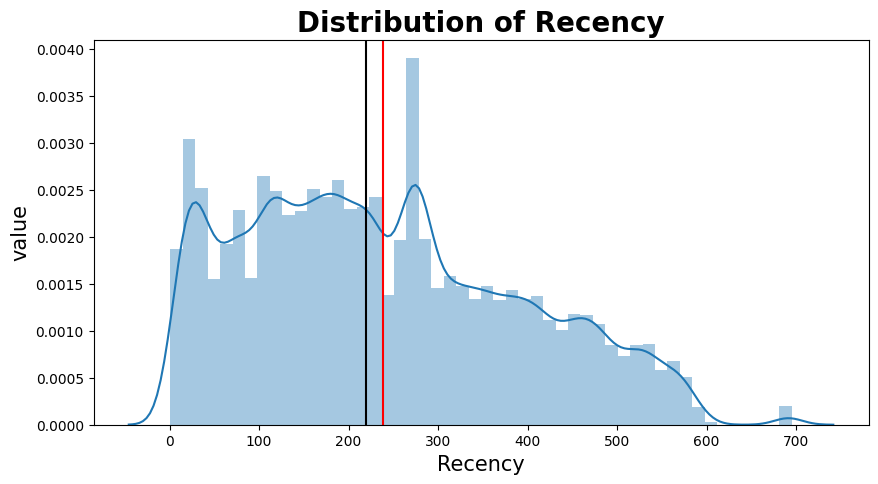

Mean of recency:  238.73377297631671
Median of recency:  220.0
Skewness of recency:  0.43585883202493925


In [12]:
plt.figure(figsize = (10, 5))
sns.distplot(rfm.Recency)
plt.axvline(rfm.Recency.mean(), c = 'red')
plt.axvline(rfm.Recency.median(), c = 'black')
plt.title('Distribution of Recency',fontweight='bold',fontsize=20)
plt.xlabel('Recency',fontsize=15,color='black')
plt.ylabel('value',fontsize=15,color='black')
plt.show()
print('Mean of recency: ', rfm.Recency.mean())
print('Median of recency: ', rfm.Recency.median())
print('Skewness of recency: ', rfm.Recency.skew())

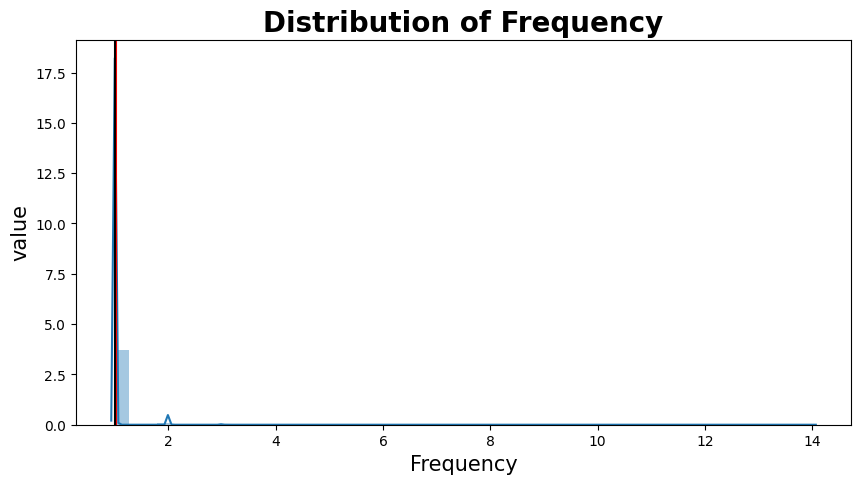

Mean of frequency:  1.0328958996111701
Median of frequency:  1.0
Skewness of frequency:  10.676600298052568


In [13]:
plt.figure(figsize = (10, 5))
sns.distplot(rfm.Frequency)
plt.axvline(rfm.Frequency.mean(), c = 'red')
plt.axvline(rfm.Frequency.median(), c = 'black')
plt.title('Distribution of Frequency',fontweight='bold',fontsize=20)
plt.xlabel('Frequency',fontsize=15,color='black')
plt.ylabel('value',fontsize=15,color='black')
plt.show()
print('Mean of frequency: ', rfm.Frequency.mean())
print('Median of frequency: ', rfm.Frequency.median())
print('Skewness of frequency: ', rfm.Frequency.skew())

In [14]:
Q1 = np.quantile(rfm.Frequency, 0.25)
Q3 = np.quantile(rfm.Frequency, 0.75)
IQR = Q3 - Q1
frequencyDistribution = rfm[~((rfm.Frequency < Q1 - 1.5 * IQR) | (rfm.Frequency > Q3 + 1.5 * IQR))]
frequencyDistribution.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


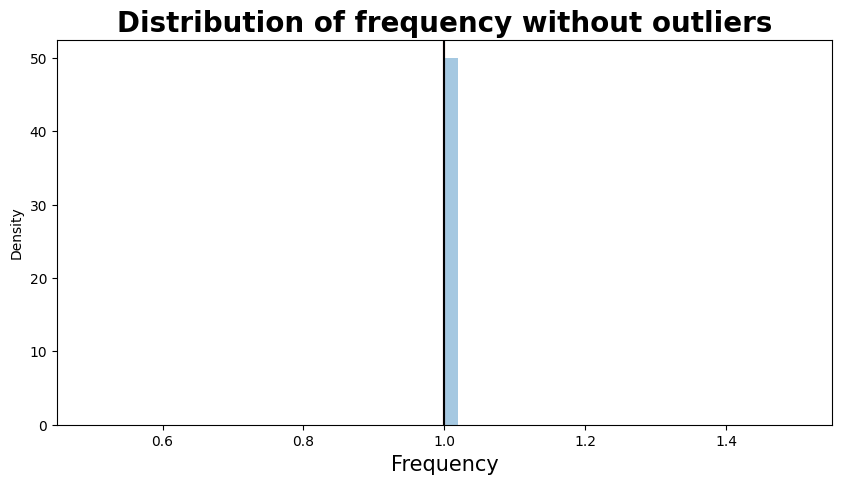

In [15]:
plt.figure(figsize=(10, 5))
sns.distplot(frequencyDistribution.Frequency)
plt.axvline(frequencyDistribution.Frequency.mean(), c = 'red')
plt.axvline(frequencyDistribution.Frequency.median(), c = 'black')
plt.xlabel('Frequency',color='black',fontsize=15)
plt.title('Distribution of frequency without outliers',color='black',fontsize=20,fontweight='bold')
plt.show()

In [16]:
frequencyDistribution.Frequency.describe()

count    87850.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Frequency, dtype: float64

**Observations:**
1. The **frequency** from RFM analysis without outliers has a **standard deviation of 0**, that is, **all the values are only 1**. 
2. So the **frequency will not help in our analysis** and also to segment the customers. 

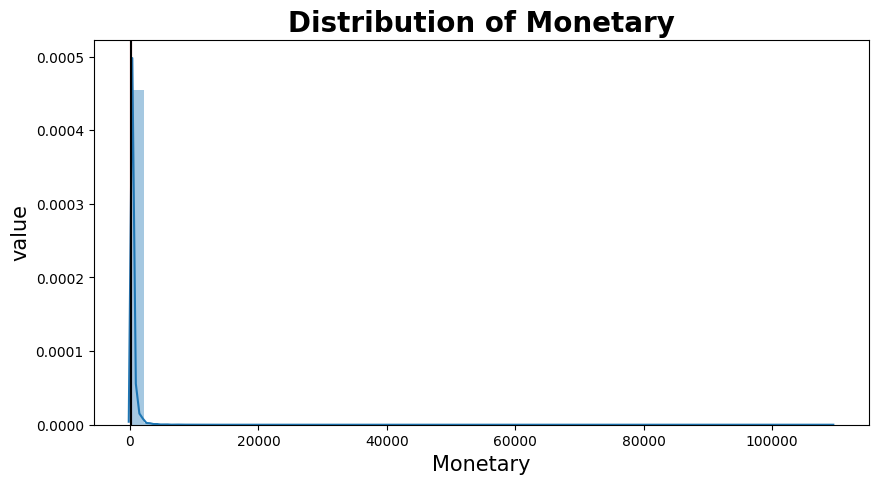

Mean of monetary:  212.23630898727467
Median of monetary:  112.83
Skewness of monetary:  70.4949829190865


In [17]:
plt.figure(figsize = (10, 5))
sns.distplot(rfm.Monetary)
plt.axvline(rfm.Monetary.mean(), c = 'red')
plt.axvline(rfm.Monetary.median(), c = 'black')
plt.title('Distribution of Monetary',fontweight='bold',fontsize=20)
plt.xlabel('Monetary',fontsize=15,color='black')
plt.ylabel('value',fontsize=15,color='black')
plt.show()
print('Mean of monetary: ', rfm.Monetary.mean())
print('Median of monetary: ', rfm.Monetary.median())
print('Skewness of monetary: ', rfm.Monetary.skew())

In [18]:
Q1 = np.quantile(rfm.Monetary, 0.25)
Q3 = np.quantile(rfm.Monetary, 0.75)
IQR = Q3 - Q1
monetaryDistribution = rfm[~((rfm.Monetary < Q1 - 1.5 * IQR) | (rfm.Monetary > Q3 + 1.5 * IQR))]
monetaryDistribution.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


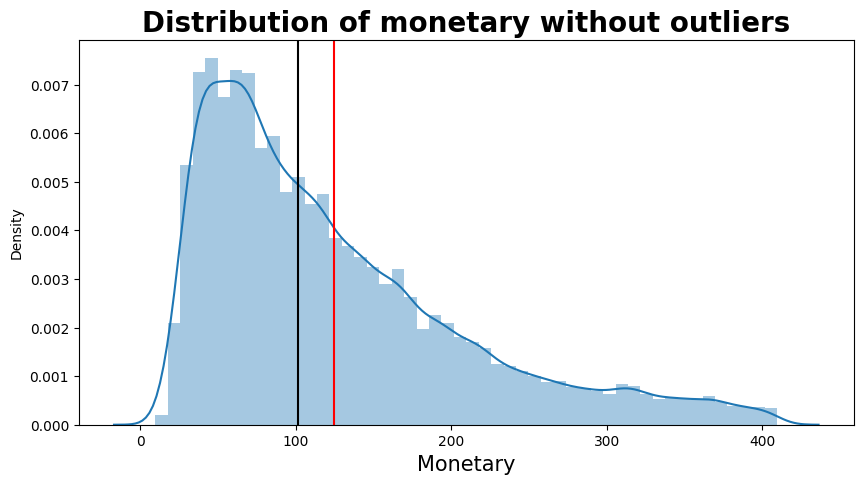

In [19]:
plt.figure(figsize=(10, 5))
sns.distplot(monetaryDistribution.Monetary)
plt.axvline(monetaryDistribution.Monetary.mean(), c = 'red')
plt.axvline(monetaryDistribution.Monetary.median(), c = 'black')
plt.xlabel('Monetary',color='black',fontsize=15)
plt.title('Distribution of monetary without outliers',color='black',fontsize=20,fontweight='bold')
plt.show()

In [20]:
monetaryDistribution.Monetary.describe()

count    81643.000000
mean       124.744198
std         85.108001
min          9.590000
25%         60.000000
50%        101.220000
75%        166.710000
max        409.610000
Name: Monetary, dtype: float64

**Observations:**
1. The average monetary value after outlier treatement is **124.74 Brazilian Real**, while the median value is **101.25 Brazilian Real**. 
2. The middle 50% of values of monetary lie between **60 and 166.71 Brazilian Real**. 

<a id="seg"></a>
# 8. Customer Segmentation

<a id="lare"></a>
## 8.1. Labels for Recency

In [21]:
ll_r = rfm.Recency.quantile(0.25)
mid_r = rfm.Recency.quantile(0.50)
ul_r = rfm.Recency.quantile(0.75)
print(ll_r, mid_r, ul_r)

115.0 220.0 347.0


In [22]:
def recency_label(recent):
    if recent <= ll_r:
        return 1
    elif (recent > ll_r) and (recent <= mid_r):
        return 2
    elif (recent > mid_r) and (recent <= ul_r):
        return 3
    elif recent > ul_r:
        return 4

In [23]:
rfm['recency_label'] = rfm.Recency.apply(recency_label)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3


**Recency label breakdown:**<br>
1 - These are the customers who whose visit date(s) are the most recent. (Recency value within the 25% quantile)<br>
2 - These are the customers who whose visit date(s) are not very recent. (Recency value between 25% and 50% quantile)<br>
3 - These are the customers who whose visit date(s) are somewhat recent. (Recency value between 50% and 75% quantile)<br>
4 - These are the customers who whose visit date(s) are the oldest. (Recency value more than 75% quantile)

<a id="lamy"></a>
## 8.2. Labels for Monetary

In [24]:
ll_m = rfm.Monetary.quantile(0.25)
mid_m = rfm.Monetary.quantile(0.50)
ul_m = rfm.Monetary.quantile(0.75)
print(ll_m, mid_m, ul_m)

63.79 112.83 202.1225


In [25]:
def monetary_label(money):
    if money <= ll_m:
        return 4
    elif (money > ll_m) and (money <= mid_m):
        return 3
    elif (money > mid_m) and (money <= ul_m):
        return 2
    elif money > ul_m:
        return 1

In [26]:
rfm['monetary_label'] = rfm.Monetary.apply(monetary_label)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label,monetary_label
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1,4
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,3
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,2


**Monetary label breakdown:**<br>
1 - These are the customers who spend large amount. (Monetary value within the 25% quantile)<br>
2 - These are the customers who spend good amount. (Monetary value between 25% and 50% quantile)<br>
3 - These are the customers who spend moderately. (Monetary value between 50% and 75% quantile)<br>
4 - These are the customers who spend the least. (Monetary value more than 75% quantile)

<a id="lafr"></a>
## 8.3. Labels for Frequency

In [27]:
rfm.Frequency.value_counts()

Frequency
1     87850
2      2462
3       171
4        28
5         9
6         3
7         3
9         1
14        1
Name: count, dtype: int64

In [28]:
def frequency_label(frequent):
    if frequent == 1:
        return 4
    elif frequent == 2:
        return 3
    elif frequent == 3:
        return 2
    elif frequent > 3:
        return 1

In [29]:
rfm['frequency_label'] = rfm.Frequency.apply(frequency_label)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label,monetary_label,frequency_label
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1,2,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1,4,4
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,3,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,2,4


**Frequency label breakdown:**<br>
1 - These are the most frequent customers. (Frequency > 3)<br>
2 - These are the frequent frequent customers. (Frequency = 3)<br>
3 - These are the somewhat frequent customers. (Frequency = 2)<br>
4 - These are the least frequent customers. (Frequency = 1)

In [30]:
rfm['Rank'] = list(zip(rfm.recency_label, rfm.monetary_label, rfm.frequency_label))
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label,monetary_label,frequency_label,Rank
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1,2,4,"(1, 2, 4)"
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1,4,4,"(1, 4, 4)"
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,3,4,"(4, 3, 4)"
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4,4,"(3, 4, 4)"
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,2,4,"(3, 2, 4)"


In [31]:
rfm.recency_label.value_counts()

recency_label
1    22754
4    22595
3    22594
2    22585
Name: count, dtype: int64

In [32]:
rfm.frequency_label.value_counts()

frequency_label
4    87850
3     2462
2      171
1       45
Name: count, dtype: int64

In [33]:
rfm.monetary_label.value_counts()

monetary_label
4    22637
1    22632
2    22630
3    22629
Name: count, dtype: int64

**Observation:**
1. Since **most of the frequency class is 4**, we will use only **recency and monetary for customer segmentation**. 

In [34]:
rfm['rank_rm'] = list(zip(rfm.recency_label, rfm.monetary_label))
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,recency_label,monetary_label,frequency_label,Rank,rank_rm
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,1,2,4,"(1, 2, 4)","(1, 2)"
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,1,4,4,"(1, 4, 4)","(1, 4)"
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,3,4,"(4, 3, 4)","(4, 3)"
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4,4,"(3, 4, 4)","(3, 4)"
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,2,4,"(3, 2, 4)","(3, 2)"


In [35]:
rfm.rank_rm.value_counts()

rank_rm
(1, 2)    5867
(3, 3)    5837
(4, 3)    5835
(1, 1)    5793
(2, 4)    5745
(4, 4)    5723
(2, 2)    5701
(3, 1)    5664
(2, 1)    5644
(1, 4)    5632
(3, 2)    5556
(3, 4)    5537
(4, 1)    5531
(4, 2)    5506
(2, 3)    5495
(1, 3)    5462
Name: count, dtype: int64

<a id="ranking"></a>
## 8.4. Meaning of ranks:
### The most important and least important customers (Recency Rank, Monetary Rank):
- Comparing Recency and Monetary - Recency rank is of higher importance than Monetary rank

### The most important ranks:
1. (Recency - 1, Monetary - 1) - They are very recent and have spend a lot of money
2. (Recency - 1, Monetary - 2) - They are very recent and have spend a good amount of money
3. (Recency - 2, Monetary - 1) - They are recent and have spend a lot of money
4. (Recency - 2, Monetary - 2) - They are recent and have spend a good of money
5. (Recency - 1, Monetary - 3) - They are very recent and have spend a decent of money

### The least important ranks:
1. (Recency - 4, Monetary - 4) - They are not at all recent and spend a negligible amount of money
2. (Recency - 4, Monetary - 3) - They are not at all recent and spend a a decent amount of money
3. (Recency - 4, Monetary - 2) - They are not at all recent and spend a good amount of money
4. (Recency - 3, Monetary - 4) - They are not very recent and spend a negligible amount of money
5. (Recency - 3, Monetary - 3) - They are not very recent and spend a decent amount of money

<a id="insights"></a>
## 8.5. Business Insights from RM analysis

**Insights from Recency Ranks:**
1. Customers can be incentivised to purchase more in our store using offers/discounts/events which will make them more recent and at the same time bring in more money
2. Customers will use our store if the website is user-friendly and quick. This will help make the customer's shopping experience smooth meaning they will continue coming back to our store/website for their purchasing needs
3. When advertising using digital marketing techniques:
    - Customers who have a low recency ranks should be targeted less or removed from advertisement lists as it will not bring as much or even returns/sales (This can also be done using customer's time spent on website but that will be for a future project)
    - Customers who have high recency ranks should be targeted more extensively as it will bring a lot of sales in return

**Insights from Monetary Ranks:**
1. Customer's monetary values can be increased with a better algorithm which will recommend similar/useful items when an item is added to cart

**Insights from Frequency Ranks:**<br>
97% (89100 out of 91832) of the customers have the lowest frequency rank (4) meaning they are very infrequent in their purchases. In order to combat this:-
1. Local language can be used in the ecommerce platform/store
2. Extend special offers for repeated purchases
3. Encourage Loyalty programs
4. Lower the Product Pricing for Increased Customer Frequency

In [36]:
# Save RFM and segmentation outputs for use in Notebook 3
rfm.to_csv("rfm.csv", index=False)
final.to_csv("final.csv", index=False)  # final may have been updated with RFM scores
print("Saved rfm.csv and final.csv")

Saved rfm.csv and final.csv
